In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
%config IPCompleter.greedy=True

## Chargement du dataset

## Observation importante :
- ### les classes du target Credit_Score sont desequilibrees dans cette echantillon et Standard en particulier a plus de la moitie des enregistrements;
- ### la presence de valeur manquante sur dans les variables Monthly_Inhand_Salary, Monthly_Balance, Num_Credit_Inquiries, Monthly_Balance, Amount_invested_monthly, Num_of_Delayed_Payment, Credit_History_Age, Name;
- ### Il y'a incoherence des types.

In [3]:
df = pd.read_csv("./data/train.csv")

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_23584\599420964.py:1: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("./data/train.csv")


## Dimension

In [4]:
df.shape

(100000, 28)

## Types 

In [5]:
df.dtypes

ID                           object
Customer_ID                  object
Month                        object
Name                         object
Age                          object
SSN                          object
Occupation                   object
Annual_Income                object
Monthly_Inhand_Salary       float64
Num_Bank_Accounts             int64
Num_Credit_Card               int64
Interest_Rate                 int64
Num_of_Loan                  object
Type_of_Loan                 object
Delay_from_due_date           int64
Num_of_Delayed_Payment       object
Changed_Credit_Limit         object
Num_Credit_Inquiries        float64
Credit_Mix                   object
Outstanding_Debt             object
Credit_Utilization_Ratio    float64
Credit_History_Age           object
Payment_of_Min_Amount        object
Total_EMI_per_month         float64
Amount_invested_monthly      object
Payment_Behaviour            object
Monthly_Balance              object
Credit_Score                

## 05 premieres lignes

In [6]:
df.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


## Statistiques descriptive

In [7]:
df.describe(include="all")

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
count,100000,100000,100000,90015,100000,100000,100000,100000,84998.000000,100000.000000,...,100000,100000,100000.000000,90970,100000,100000.000000,95521,100000,98800,100000
unique,100000,12500,8,10139,1788,12501,16,18940,NaN,NaN,...,4,13178,NaN,404,3,NaN,91049,7,98792,3
top,0x1602,CUS_0xd40,January,Langep,38,#F%$D@*&8,_______,36585.12,NaN,NaN,...,Standard,1360.45,NaN,15 Years and 11 Months,Yes,NaN,__10000__,Low_spent_Small_value_payments,__-333333333333333333333333333__,Standard
freq,1,8,12500,44,2833,5572,7062,16,NaN,NaN,...,36479,24,NaN,446,52326,NaN,4305,25513,9,53174
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4194.170850,17.091280,...,NaN,NaN,32.285173,NaN,NaN,1403.118217,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3183.686167,117.404834,...,NaN,NaN,5.116875,NaN,NaN,8306.041270,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,303.645417,-1.000000,...,NaN,NaN,20.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1625.568229,3.000000,...,NaN,NaN,28.052567,NaN,NaN,30.306660,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3093.745000,6.000000,...,NaN,NaN,32.305784,NaN,NaN,69.249473,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5957.448333,7.000000,...,NaN,NaN,36.496663,NaN,NaN,161.224249,NaN,NaN,NaN,NaN


## Valeurs manquantes

In [8]:
df.isnull().sum().sort_values(ascending=False)

Monthly_Inhand_Salary       15002
Type_of_Loan                11408
Name                         9985
Credit_History_Age           9030
Num_of_Delayed_Payment       7002
Amount_invested_monthly      4479
Num_Credit_Inquiries         1965
Monthly_Balance              1200
ID                              0
Changed_Credit_Limit            0
Payment_Behaviour               0
Total_EMI_per_month             0
Payment_of_Min_Amount           0
Credit_Utilization_Ratio        0
Outstanding_Debt                0
Credit_Mix                      0
Delay_from_due_date             0
Customer_ID                     0
Num_of_Loan                     0
Interest_Rate                   0
Num_Credit_Card                 0
Num_Bank_Accounts               0
Annual_Income                   0
Occupation                      0
SSN                             0
Age                             0
Month                           0
Credit_Score                    0
dtype: int64

## Nombre de doublons

In [9]:
df.duplicated().sum()

np.int64(0)

## Modalite du target

In [10]:
df["Credit_Score"].value_counts()

Credit_Score
Standard    53174
Poor        28998
Good        17828
Name: count, dtype: int64

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_23584\2758512488.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df, x="Credit_Score", order=df["Credit_Score"].value_counts().index, palette="viridis")


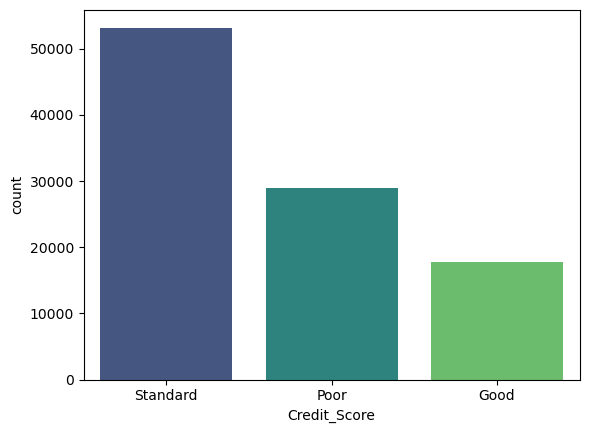

In [11]:
sns.countplot(df, x="Credit_Score", order=df["Credit_Score"].value_counts().index, palette="viridis")
plt.show()

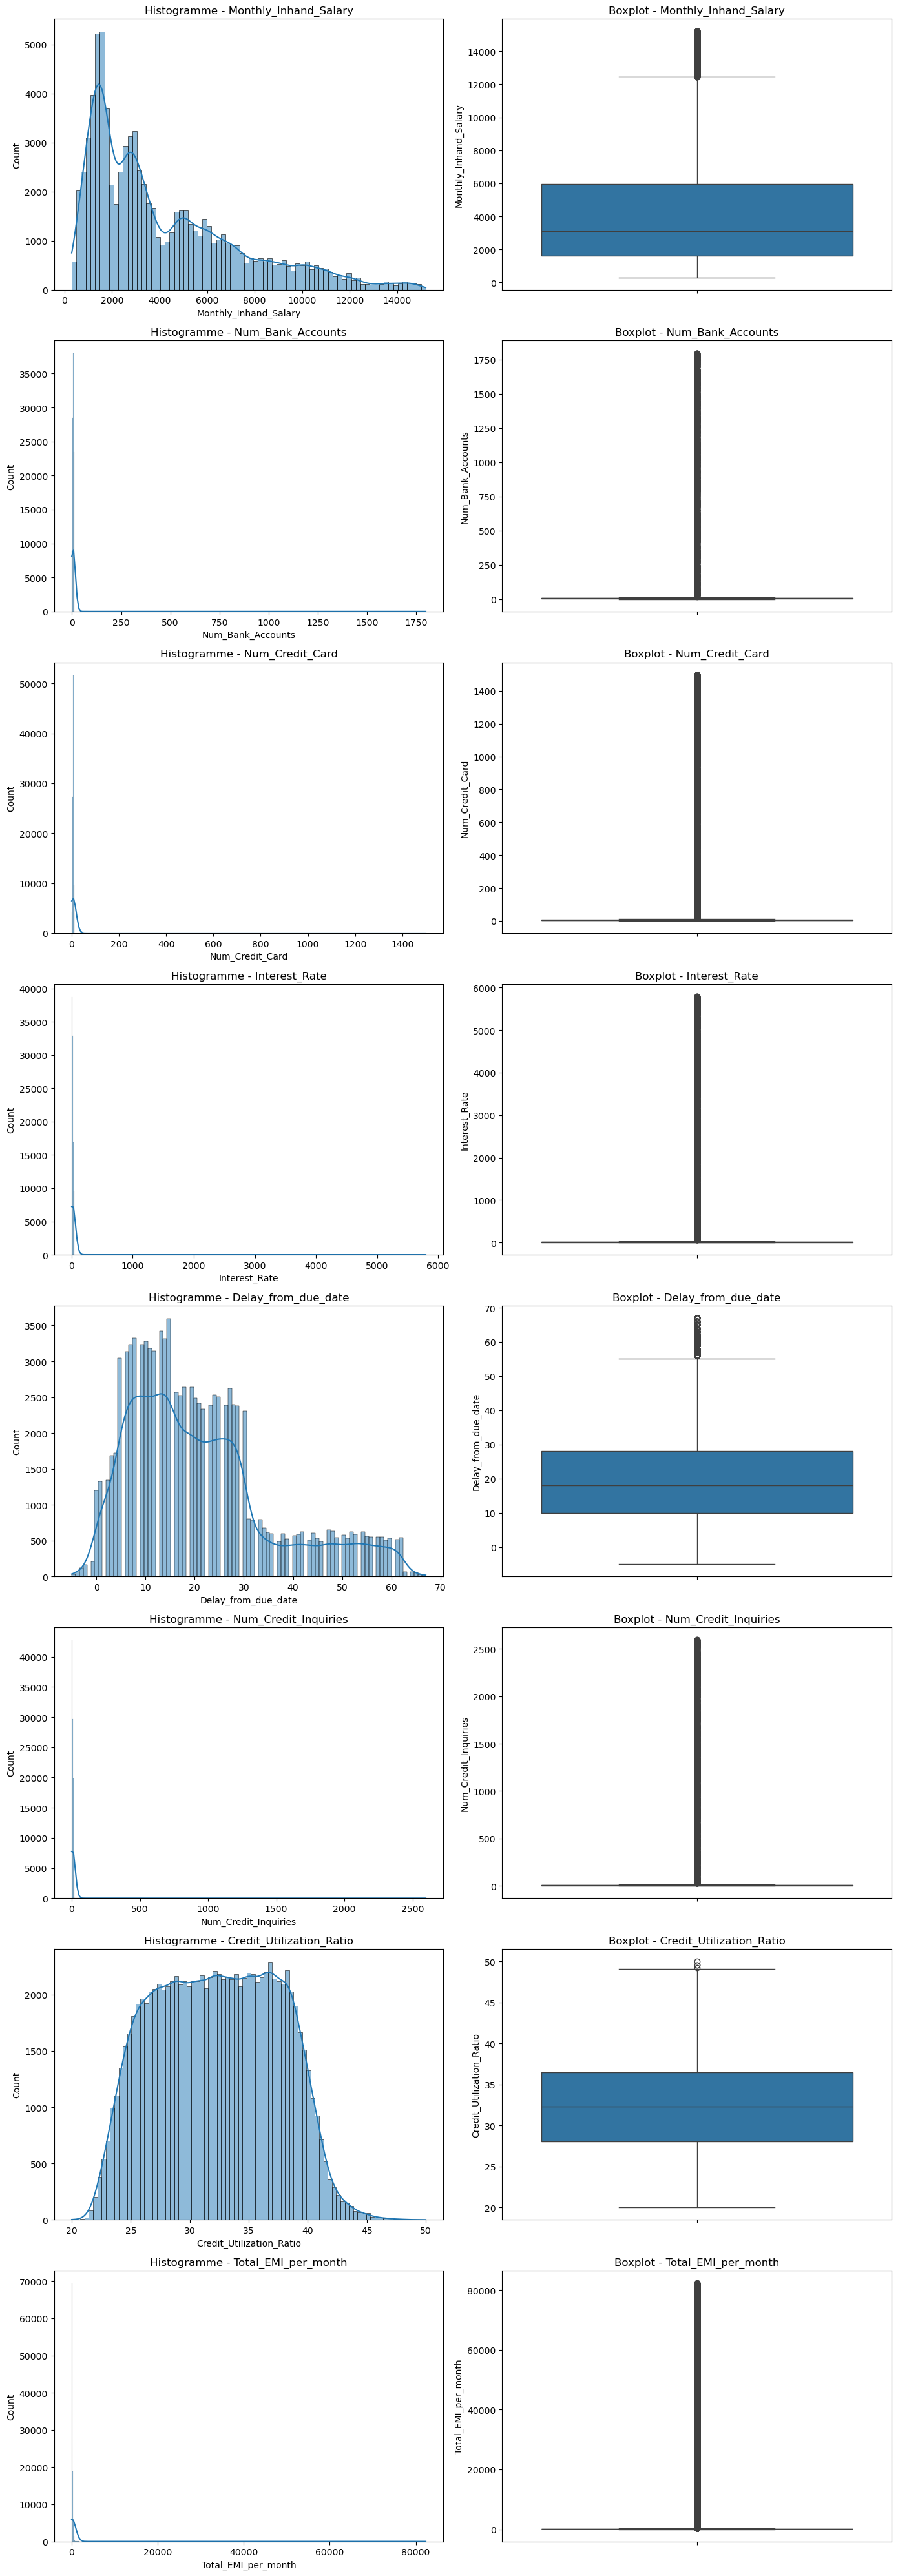

In [12]:
# Colonnes numériques
cols = df.select_dtypes(include="number").columns

# Nombre de variables
n = len(cols)

# Création des subplots
fig, axes = plt.subplots(
    nrows=n,
    ncols=2,
    figsize=(14, 5*n)
)

# Si une seule variable
if n == 1:
    axes = [axes]

# Boucle
for i, col in enumerate(cols):
    
    # Histogramme
    sns.histplot(
        data=df,
        x=col,
        kde=True,
        edgecolor="black",
        ax=axes[i,0]
    )
    
    axes[i,0].set_title(f"Histogramme - {col}")
    
    # Boxplot
    sns.boxplot(
        data=df,
        y=col,
        ax=axes[i,1]
    )
    
    axes[i,1].set_title(f"Boxplot - {col}")

# Ajustement
plt.tight_layout()

plt.show()

In [13]:
print(df["Credit_History_Age"].isnull().sum())

9030


In [14]:
df["Credit_History_Age"] = (
    df["Credit_History_Age"]
    .astype(str)
    .str.extract(r"(\d+)\s*Years?")[0].astype(float) * 12
    +
    df["Credit_History_Age"]
    .astype(str)
    .str.extract(r"(\d+)\s*Month")[0].astype(float).fillna(0)
)

In [15]:
df["Credit_History_Age"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 100000 entries, 0 to 99999
Series name: Credit_History_Age
Non-Null Count  Dtype  
--------------  -----  
90970 non-null  float64
dtypes: float64(1)
memory usage: 781.4 KB


In [16]:
df["Credit_History_Age"].head(25)

0     265.0
1       NaN
2     267.0
3     268.0
4     269.0
5     270.0
6     271.0
7       NaN
8     319.0
9     320.0
10    321.0
11    322.0
12    323.0
13    324.0
14    325.0
15    326.0
16    213.0
17    214.0
18    215.0
19      NaN
20    217.0
21    218.0
22    219.0
23    220.0
24    207.0
Name: Credit_History_Age, dtype: float64